# UniTable Confidence vs TEDS

Tests whether the structure decoder's mean log probability per table correlates with TEDS score.

**Hypothesis:** Tables where UniTable generates each structure token with high confidence (mean log prob close to 0) should have high TEDS. Tables where the model is uncertain (mean log prob far from 0) should have low TEDS.

If the correlation is strong, mean log prob is a zero-training pre-filter — no separate model, no labels needed.

**Test set:** same 70/15/15 split used during classifier training — 2,644 tables with known TEDS scores.

In [ ]:
import sys, os, re
from pathlib import Path
from functools import partial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from scipy import stats

import torch
import torch.nn as nn
import tokenizers as tk
from PIL import Image
from torchvision import transforms

ROOT         = Path("..")
UNITABLE_SRC = ROOT / "Huma-Huma" / "unitable"
sys.path.insert(0, str(UNITABLE_SRC))

from src.model import EncoderDecoder, ImgLinearBackbone, Encoder, Decoder
from src.utils import (
    subsequent_mask, pred_token_within_range, greedy_sampling,
    html_str_to_token_list,
)
from src.vocab import HTML_TOKENS

VALID_HTML_TOKEN = ["<eos>"] + HTML_TOKENS

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

## 1. Reconstruct the test split

In [ ]:
SEED = 42

# Load both label CSVs — same files used in training
df_icdar  = pd.read_csv(ROOT / "teds_labels_20260410_030718.csv")
df_icdar["source"] = "icdar"

df_pubtab = pd.read_csv(ROOT / "teds_labels_pubtabnet_full_20260411_200347.csv")

df = pd.concat([df_icdar, df_pubtab], ignore_index=True)
df_clean = df[df["label"].isin([0, 1]) & (df["teds_score"] >= 0)].copy()

# Exact same split as training
_, df_temp = train_test_split(df_clean, test_size=0.30, stratify=df_clean["label"], random_state=SEED)
_, df_test = train_test_split(df_temp,  test_size=0.50, stratify=df_temp["label"],  random_state=SEED)

print(f"Test set: {len(df_test)} tables")
print(f"  Label 1 (positive): {(df_test['label']==1).sum()}")
print(f"  Label 0 (negative): {(df_test['label']==0).sum()}")
print(f"  ICDAR:     {(df_test['source']=='icdar').sum()}")
print(f"  PubTabNet: {(df_test['source']=='pubtabnet').sum()}")

# Image path resolver
ICDAR_IMAGES  = ROOT / "Training set for encoder binary classifier pipeline" / "icdar-task-b" / "final_eval"
PUBTAB_IMAGES = ROOT / "pubtabnet" / "images"

def img_path(row):
    source = row.get("source", "icdar")
    if source == "pubtabnet":
        return PUBTAB_IMAGES / row["filename"]
    return ICDAR_IMAGES / row["filename"]

## 2. Load UniTable structure model

In [ ]:
WEIGHTS = UNITABLE_SRC / "experiments" / "unitable_weights"
VOCAB   = UNITABLE_SRC / "vocab"

D_MODEL    = 768
PATCH_SIZE = 16
NHEAD      = 12
MEAN = [0.86597056, 0.88463002, 0.87491087]
STD  = [0.20686628, 0.18201602, 0.18485524]

vocab_html = tk.Tokenizer.from_file(str(VOCAB / "vocab_html.json"))
backbone   = ImgLinearBackbone(d_model=D_MODEL, patch_size=PATCH_SIZE)
encoder    = Encoder(d_model=D_MODEL, nhead=NHEAD, dropout=0.2,
                     activation="gelu", norm_first=True, nlayer=12, ff_ratio=4)
decoder    = Decoder(d_model=D_MODEL, nhead=NHEAD, dropout=0.2,
                     activation="gelu", norm_first=True, nlayer=4, ff_ratio=4)

full_model = EncoderDecoder(
    backbone=backbone, encoder=encoder, decoder=decoder,
    vocab_size=vocab_html.get_vocab_size(), d_model=D_MODEL,
    padding_idx=vocab_html.token_to_id("<pad>"),
    max_seq_len=784, dropout=0.2,
    norm_layer=partial(nn.LayerNorm, eps=1e-6),
)
full_model.load_state_dict(
    torch.load(WEIGHTS / "unitable_large_structure.pt", map_location="cpu", weights_only=True)
)
model_html = full_model.to(device).eval()
print("Structure model loaded.")

## 3. Inference with confidence capture

Modified decoder that records the log probability of each chosen token and returns the mean.

In [ ]:
transform = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

def pad_to_square(image, fill=255):
    w, h = image.size
    max_dim = max(w, h)
    padded = Image.new("RGB", (max_dim, max_dim), (fill, fill, fill))
    padded.paste(image, ((max_dim - w) // 2, (max_dim - h) // 2))
    return padded

def structure_with_confidence(image: Image.Image, max_len=512):
    """
    Run the structure decoder on one image.
    Returns (token_ids, mean_log_prob).
    
    At each autoregressive step:
      - compute log_softmax over full vocab
      - record the log prob of the chosen token
    Mean log prob across all steps = confidence score.
    Close to 0 → high confidence. More negative → more uncertain.
    """
    img_t = transform(pad_to_square(image)).unsqueeze(0).to(device)

    eos_id    = vocab_html.token_to_id("<eos>")
    whitelist = [vocab_html.token_to_id(i) for i in VALID_HTML_TOKEN]
    prefix    = [vocab_html.token_to_id("[html]")]

    log_prob_sum = 0.0
    token_count  = 0

    with torch.no_grad():
        memory  = model_html.encode(img_t)
        context = torch.tensor(prefix, dtype=torch.int32).unsqueeze(0).to(device)

    for _ in range(max_len):
        if eos_id in context[0]:
            break
        with torch.no_grad():
            mask   = subsequent_mask(context.shape[1]).to(device)
            logits = model_html.decode(memory, context, tgt_mask=mask, tgt_padding_mask=None)
            logits = model_html.generator(logits)[:, -1, :]   # (1, vocab_size)

        # Log prob over full vocab — BEFORE whitelist filtering
        log_probs = torch.log_softmax(logits, dim=-1)          # (1, vocab_size)

        # Apply whitelist, pick token
        logits_filtered = pred_token_within_range(logits.detach(), white_list=whitelist)
        _, next_tok     = greedy_sampling(logits_filtered)     # (1, 1)

        # Record log prob of chosen token
        chosen_id        = next_tok[0, 0].item()
        log_prob_sum    += log_probs[0, chosen_id].item()
        token_count     += 1

        context = torch.cat([context, next_tok], dim=1)

    mean_log_prob = log_prob_sum / token_count if token_count > 0 else float("-inf")
    return context, mean_log_prob

## 4. Run on test set sample

Adjust `N_SAMPLE` to control how many tables to run. 300 takes ~15 min on MPS.

In [ ]:
from tqdm import tqdm
import glob

# ── Option A: load pre-computed results from Modal run ────────────────────────
PRECOMPUTED = sorted(glob.glob(str(ROOT / "confidence_scores_*.csv")))
if PRECOMPUTED:
    latest = PRECOMPUTED[-1]
    results = pd.read_csv(latest)
    print(f"Loaded pre-computed results from: {latest}")
    print(f"{len(results)} tables  "
          f"(label=1: {(results['label']==1).sum()}  label=0: {(results['label']==0).sum()})")
    print(results[["teds_score", "mean_log_prob"]].describe())

# ── Option B: run locally (slow — set N_SAMPLE small for a quick test) ────────
else:
    N_SAMPLE = 1

    n_pos = int(N_SAMPLE * (df_test["label"] == 1).sum() / len(df_test))
    n_neg = N_SAMPLE - n_pos
    sample_pos = df_test[df_test["label"] == 1].sample(n=min(n_pos, (df_test["label"] == 1).sum()), random_state=SEED)
    sample_neg = df_test[df_test["label"] == 0].sample(n=min(n_neg, (df_test["label"] == 0).sum()), random_state=SEED)
    df_sample = pd.concat([sample_pos, sample_neg]).reset_index(drop=True)

    print(f"No pre-computed file found — running locally on {len(df_sample)} tables  "
          f"(label=1: {(df_sample['label']==1).sum()}  label=0: {(df_sample['label']==0).sum()})")

    records = []
    for _, row in tqdm(df_sample.iterrows(), total=len(df_sample)):
        path = img_path(row)
        if not path.exists():
            continue
        try:
            image = Image.open(path).convert("RGB")
            _, mean_lp = structure_with_confidence(image)
            records.append({
                "filename":      row["filename"],
                "source":        row.get("source", "icdar"),
                "teds_score":    row["teds_score"],
                "label":         int(row["label"]),
                "mean_log_prob": mean_lp,
            })
        except Exception as e:
            print(f"Error {row['filename']}: {e}")

    results = pd.DataFrame(records)
    print(f"\nDone — {len(results)} tables processed")
    print(results[["teds_score", "mean_log_prob"]].describe())

## 5. Visualise

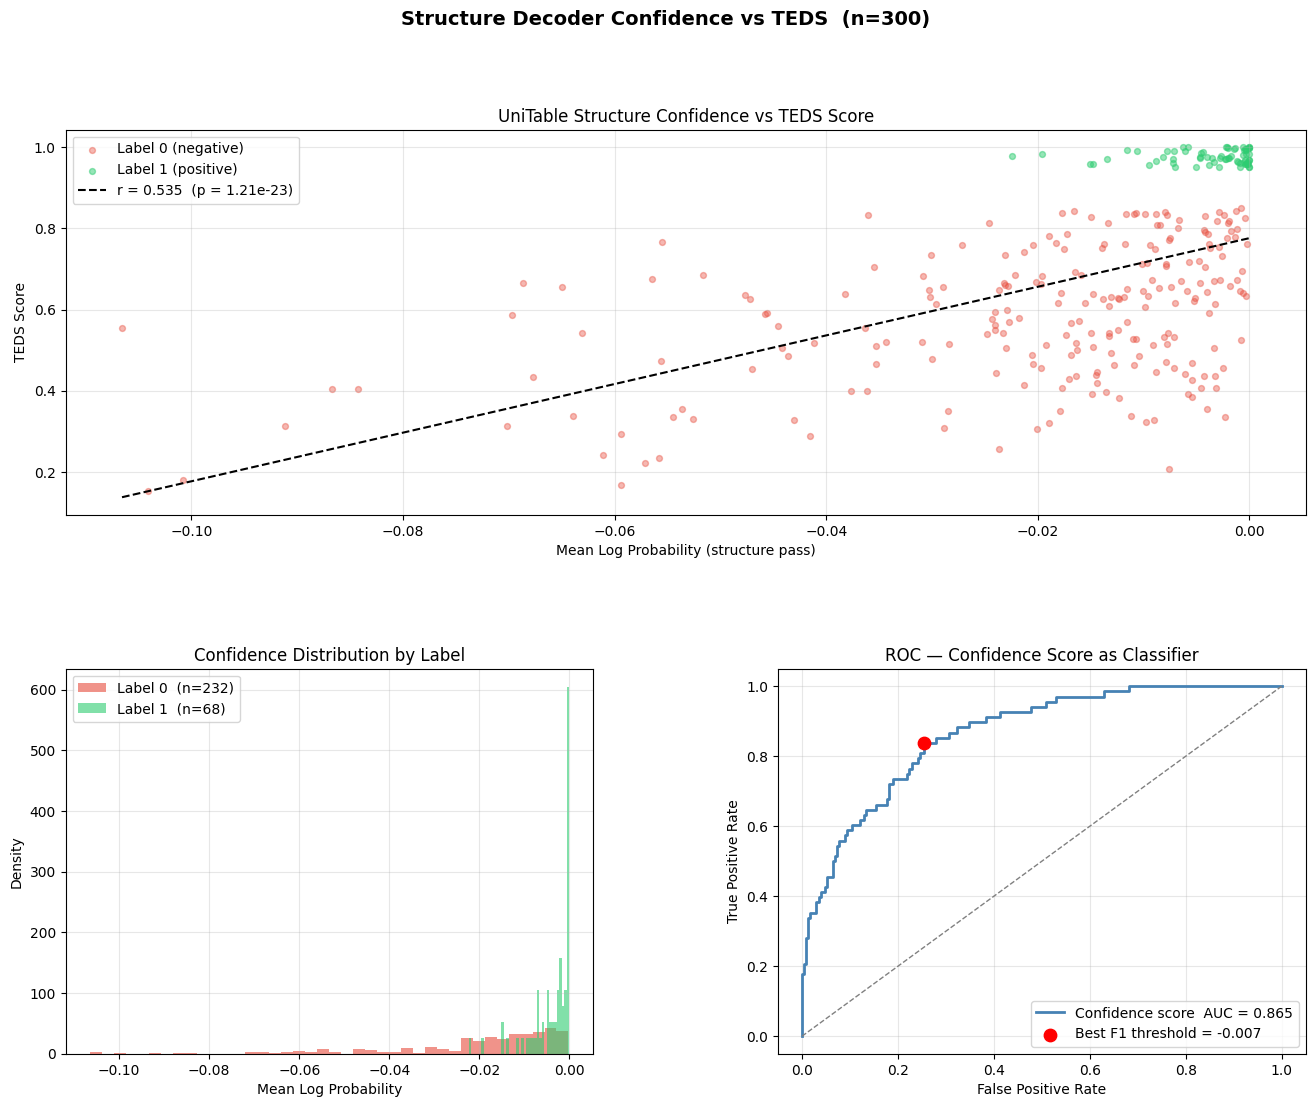


Pearson r: 0.5353  (p=1.21e-23)
ROC-AUC:   0.8650
Optimal threshold: -0.0073

For comparison — trained classifier ROC-AUC: 0.58–0.66


In [12]:
import os
os.makedirs("results", exist_ok=True)

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

pos = results[results["label"] == 1]
neg = results[results["label"] == 0]

# ── Panel 1: Scatter confidence vs TEDS ───────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.scatter(neg["mean_log_prob"], neg["teds_score"],
            alpha=0.4, s=18, color="#e74c3c", label="Label 0 (negative)")
ax1.scatter(pos["mean_log_prob"], pos["teds_score"],
            alpha=0.5, s=18, color="#2ecc71", label="Label 1 (positive)")

# Regression line
r, p = stats.pearsonr(results["mean_log_prob"], results["teds_score"])
m, b = np.polyfit(results["mean_log_prob"], results["teds_score"], 1)
x_line = np.linspace(results["mean_log_prob"].min(), results["mean_log_prob"].max(), 100)
ax1.plot(x_line, m * x_line + b, color="black", linewidth=1.5, linestyle="--",
         label=f"r = {r:.3f}  (p = {p:.2e})")

ax1.set_xlabel("Mean Log Probability (structure pass)")
ax1.set_ylabel("TEDS Score")
ax1.set_title("UniTable Structure Confidence vs TEDS Score")
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── Panel 2: Confidence distribution by label ──────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(neg["mean_log_prob"], bins=40, alpha=0.6, color="#e74c3c",
         label=f"Label 0  (n={len(neg)})", density=True)
ax2.hist(pos["mean_log_prob"], bins=40, alpha=0.6, color="#2ecc71",
         label=f"Label 1  (n={len(pos)})", density=True)
ax2.set_xlabel("Mean Log Probability")
ax2.set_ylabel("Density")
ax2.set_title("Confidence Distribution by Label")
ax2.legend()
ax2.grid(True, alpha=0.3)

# ── Panel 3: ROC curve ─────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
fpr, tpr, thresholds = roc_curve(results["label"], results["mean_log_prob"])
auc = roc_auc_score(results["label"], results["mean_log_prob"])

ax3.plot(fpr, tpr, color="steelblue", linewidth=2,
         label=f"Confidence score  AUC = {auc:.3f}")
ax3.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1)

# Mark the optimal threshold (max F1)
f1s = 2 * tpr * (1 - fpr) / (tpr + (1 - fpr) + 1e-8)
best_idx = f1s.argmax()
ax3.scatter(fpr[best_idx], tpr[best_idx], color="red", zorder=5, s=80,
            label=f"Best F1 threshold = {thresholds[best_idx]:.3f}")

ax3.set_xlabel("False Positive Rate")
ax3.set_ylabel("True Positive Rate")
ax3.set_title("ROC — Confidence Score as Classifier")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.suptitle(f"Structure Decoder Confidence vs TEDS  (n={len(results)})",
             fontsize=14, fontweight="bold")
plt.savefig("results/confidence_vs_teds.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nPearson r: {r:.4f}  (p={p:.2e})")
print(f"ROC-AUC:   {auc:.4f}")
print(f"Optimal threshold: {thresholds[best_idx]:.4f}")
print(f"\nFor comparison — trained classifier ROC-AUC: 0.58–0.66")

## 6. Threshold analysis

At the optimal threshold: how many tables would be filtered, and at what precision/recall?

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

thresholds_to_try = [-0.0009, -0.0008, -0.0007, -0.0006, -0.0005,
                     -0.0004, -0.0003, -0.0002, -0.0001]

rows = []
for thresh in thresholds_to_try:
    preds = (results["mean_log_prob"] >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(results["label"], preds, labels=[0, 1]).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    blocked   = tn + fn
    rows.append({
        "threshold":          thresh,
        "precision":          round(precision, 3),
        "recall":             round(recall, 3),
        "f1":                 round(f1, 3),
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,
        "blocked":            blocked,
        "blocked_%":          round(100 * blocked / len(preds), 1),
        "false_blocks":       fn,   # positives incorrectly sent to human review
    })

df_thresh = pd.DataFrame(rows)
print(df_thresh.to_string(index=False))